In [1]:
import pandas as pd

In [2]:
ece = pd.read_excel('board2.xlsx')
ece

,Name,Gender,Track,Hometown,Math,Electronics,GEAS,Communication
0,S1,Male,Instrumentation,Luzon,58,89,75,78
1,S2,Female,Communication,Mindanao,52,75,90,52
2,S3,Female,Instrumentation,Mindanao,83,74,77,57
3,S4,Male,Instrumentation,Visayas,65,58,91,68
4,S5,Male,Communication,Luzon,59,86,43,88
5,S6,Female,Microelectronics,Visayas,88,45,86,83
6,S7,Female,Instrumentation,Luzon,66,60,60,48
7,S8,Male,Instrumentation,Luzon,49,81,64,53
8,S9,Male,Instrumentation,Luzon,50,36,63,42
9,S10,Male,Microelectronics,Mindanao,80,84,61,44


In [19]:
# A. VISAYAS COMMUNICATION DATAFRAME
# Filter BOTH conditions first, THEN select columns
VisComm = df[(df['Hometown'] == 'Visayas') & (df['Track'] == 'Communication')][
    ['Name', 'Gender', 'Math', 'Electronics', 'Average']
]

print("VisComm DataFrame:")
display(VisComm)

print(f"\nNumber of rows in VisComm: {VisComm.shape[0]}")

VisComm DataFrame:


,Name,Gender,Math,Electronics,Average
10,S11,Female,48,56,67
11,S12,Male,89,67,64
17,S18,Male,81,40,52
21,S22,Female,64,39,58
27,S28,Male,85,53,53



Number of rows in VisComm: 5


In [20]:
# B. VISAYAS FEMALE DATAFRAME
VisFemale = df[(df['Hometown'] == 'Visayas') & (df['Gender'] == 'Female')][
    ['Name', 'Track', 'GEAS', 'Electronics', 'Average']
]
display(VisFemale)

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,83
10,S11,Communication,48,56,67
20,S21,Microelectronics,68,51,72
21,S22,Communication,89,39,58
23,S24,Microelectronics,60,45,41
25,S26,Instrumentation,83,47,62


In [21]:
VisFemale_high = VisFemale[VisFemale['Average'] >= 60]
display(VisFemale_high)

,Name,Track,GEAS,Electronics,Average
5,S6,Microelectronics,86,45,83
10,S11,Communication,48,56,67
20,S21,Microelectronics,68,51,72
25,S26,Instrumentation,83,47,62


In [40]:
mean_by_track    = df.groupby('Track')['Average'].mean()
mean_by_gender   = df.groupby('Gender')['Average'].mean()
mean_by_hometown = df.groupby('Hometown')['Average'].mean()

display("Mean Average by Track:");    display(mean_by_track)
display("Mean Average by Gender:");   display(mean_by_gender)
display("Mean Average by Hometown:"); display(mean_by_hometown)

'Mean Average by Track:'

Track
Communication       64.2
Instrumentation     57.3
Microelectronics    64.4
Name: Average, dtype: float64

'Mean Average by Gender:'

Gender
Female    63.533333
Male      60.400000
Name: Average, dtype: float64

'Mean Average by Hometown:'

Hometown
Luzon       60.166667
Mindanao    61.571429
Visayas     64.181818
Name: Average, dtype: float64

In [41]:
# Part C-a: mean of Average per category, kept as DataFrames for indexing
mean_by_track    = df.groupby('Track',    as_index=False)['Average'].mean()
mean_by_gender   = df.groupby('Gender',   as_index=False)['Average'].mean()
mean_by_hometown = df.groupby('Hometown', as_index=False)['Average'].mean()

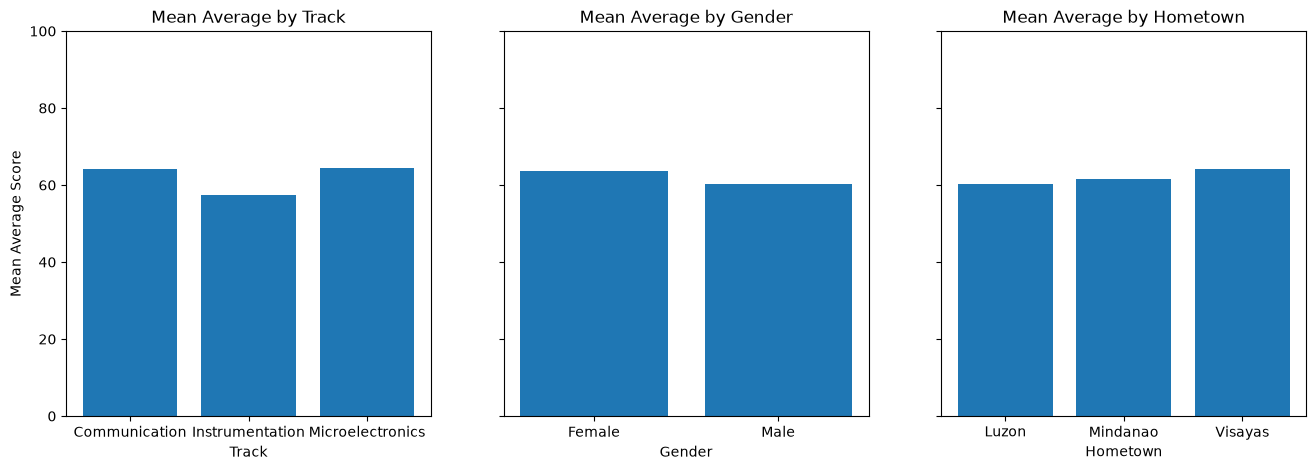

In [42]:
# C. CATEGORY-AVERAGE VISUALIZATION
#This creates a figure with 3 different subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

#Track
axes[0].bar(mean_by_track['Track'], mean_by_track['Average']) 
axes[0].set_title('Mean Average by Track') #This sets the title
axes[0].set_xlabel('Track') #This sets the label for the x-axis
axes[0].set_ylabel('Mean Average Score') #This sets the label for the y-axis
axes[0].set_ylim(0, 100)

#Gender
axes[1].bar(mean_by_gender['Gender'], mean_by_gender['Average'])
axes[1].set_title('Mean Average by Gender')
axes[1].set_xlabel('Gender')
axes[1].set_ylim(0, 100)

# Plot 3: Hometown
axes[2].bar(mean_by_hometown['Hometown'], mean_by_hometown['Average'])
axes[2].set_title('Mean Average by Hometown')
axes[2].set_xlabel('Hometown')
axes[2].set_ylim(0, 100)

plt.show()

In [26]:
# D. Interpretation: category with highest sample mean per feature
print("Track with highest mean Average:   ",
      mean_by_track.idxmax(), f"({mean_by_track.max():.2f})")
print("Gender with highest mean Average:  ",
      mean_by_gender.idxmax(), f"({mean_by_gender.max():.2f})")
print("Hometown with highest mean Average:",
      mean_by_hometown.idxmax(), f"({mean_by_hometown.max():.2f})")

Track with highest mean Average:    Microelectronics (64.40)
Gender with highest mean Average:   Female (63.53)
Hometown with highest mean Average: Visayas (64.18)
